# **Crash cource in data engineering - Chapter 5**

Creating a sample dataset

In [ ]:
import pandas as pd
import numpy as np

def create_dataset(num_rows=2000, missing_frac=0.05, outlier_frac=0.01, duplicate_frac=0.02):
    """
    Create synthetic dataset with missing values, outliers, and duplicate records.
    Keeps all columns in a single dataset (no splitting).

    Parameters:
        num_rows (int): Number of rows in dataset (default = 2000)
        missing_frac (float): Fraction of missing values per selected column (default = 0.05)
        outlier_frac (float): Fraction of outliers to inject in numeric columns (default = 0.01)
        duplicate_frac (float): Fraction of duplicate records to inject (default = 0.02)

    Returns:
        None (saves dataset.csv)
    """

    np.random.seed(42)  # For reproducibility

    # ----- Generate sample data -----
    data = {
        "ID": range(10001, 10001 + num_rows),
        "Birth Year": np.random.randint(1950, 2000, num_rows),
        "Education": np.random.choice(["Graduation", "PhD", "Master", "2n Cycle"], num_rows),
        "Marital Status": np.random.choice(["Single", "Married", "Together", "Divorced"], num_rows),
        "Income": np.random.randint(20000, 100000, num_rows),
        "Kids Home": np.random.randint(0, 3, num_rows),
        "Teens Home": np.random.randint(0, 3, num_rows),
        "Dt_Customer": pd.to_datetime(np.random.choice(pd.date_range("2012-01-01", "2014-12-31"), num_rows)),
        "Recency": np.random.randint(0, 100, num_rows),
        "Num Own Website Purchases": np.random.randint(0, 10, num_rows),
        "Num Social Media Purchases": np.random.randint(0, 10, num_rows),
        "Amount": np.random.randint(50, 20000, num_rows)
    }

    df = pd.DataFrame(data)

    # ----- Introduce missing values -----
    for col in ["Birth Year", "Education", "Income", "Kids Home", "Amount"]:
        df.loc[df.sample(frac=missing_frac, random_state=np.random.randint(1000)).index, col] = np.nan

    # ----- Inject Outliers -----
    numeric_cols = ["Income", "Amount", "Recency"]
    for col in numeric_cols:
        n_outliers = int(num_rows * outlier_frac)
        outlier_idx = np.random.choice(df.index, n_outliers, replace=False)

        if col == "Income":
            df.loc[outlier_idx, col] = df[col].mean() * 10
        elif col == "Amount":
            df.loc[outlier_idx, col] = df[col].max() * 20
        elif col == "Recency":
            df.loc[outlier_idx, col] = df[col].max() + 500

    # ----- Inject Duplicate Records -----
    n_duplicates = int(num_rows * duplicate_frac)
    dup_rows = df.sample(n=n_duplicates, random_state=123)
    df = pd.concat([df, dup_rows], ignore_index=True)  # Append duplicates

    # ----- Save as single dataset -----
    df.to_csv("dataset.csv", index=False)

    print(
        f"""File created: dataset.csv
Rows: {len(df)}, Missing fraction: {missing_frac:.0%}, Outliers fraction: {outlier_frac:.0%}, Duplicates: {duplicate_frac:.0%}
Includes missing values + injected outliers + duplicates for testing data cleaning/imputation."""
    )

# Example usage
create_dataset()


File created: dataset.csv
Rows: 2040, Missing fraction: 5%, Outliers fraction: 1%, Duplicates: 2%
Includes missing values + injected outliers + duplicates for testing data cleaning/imputation.


In [ ]:
dataset = pd.read_csv("dataset.csv")
print(dataset.columns)

Index(['ID', 'Birth Year', 'Education', 'Marital Status', 'Income',
       'Kids Home', 'Teens Home', 'Dt_Customer', 'Recency',
       'Num Own Website Purchases', 'Num Social Media Purchases', 'Amount'],
      dtype='object')


**Data sourcing :** Collecting the dataset for analysis

In [ ]:
import pandas as pd

dataset = pd.read_csv("dataset.csv")
dataset.head()

#

,ID,Birth Year,Education,Marital Status,Income,Kids Home,Teens Home,Dt_Customer,Recency,Num Own Website Purchases,Num Social Media Purchases,Amount
0,10001,1988.0,NaN,Single,26476.0,2.0,2,2014-11-22,36,1,1,16498.0
1,10002,1978.0,Master,Married,71756.0,0.0,1,2012-07-22,83,9,3,18671.0
2,10003,1964.0,Master,Together,22382.0,2.0,1,2013-06-01,47,0,8,399940.0
3,10004,1992.0,PhD,Single,NaN,1.0,1,2013-05-31,53,9,3,16606.0
4,10005,NaN,Graduation,Single,65276.0,2.0,2,2013-03-18,47,3,4,15144.0


In [ ]:
dataset.head()

,ID,Birth Year,Education,Marital Status,Income,Kids Home,Teens Home,Dt_Customer,Recency,Num Own Website Purchases,Num Social Media Purchases,Amount
0,10001,1988.0,NaN,Single,26476.0,2.0,2,2014-11-22,36,1,1,16498.0
1,10002,1978.0,Master,Married,71756.0,0.0,1,2012-07-22,83,9,3,18671.0
2,10003,1964.0,Master,Together,22382.0,2.0,1,2013-06-01,47,0,8,399940.0
3,10004,1992.0,PhD,Single,NaN,1.0,1,2013-05-31,53,9,3,16606.0
4,10005,NaN,Graduation,Single,65276.0,2.0,2,2013-03-18,47,3,4,15144.0


Summary Statistics

In [ ]:
summary_stats = dataset.describe()
print(summary_stats)

                 ID   Birth Year         Income    Kids Home   Teens Home  \
count   2040.000000  1940.000000    1941.000000  1939.000000  2040.000000   
mean   11001.975490  1974.978351   64960.290325     1.003094     0.961275   
std      577.527323    14.288725   59879.904846     0.802467     0.816078   
min    10001.000000  1950.000000   20060.000000     0.000000     0.000000   
25%    10503.750000  1963.000000   39385.000000     0.000000     0.000000   
50%    11001.500000  1975.000000   59019.000000     1.000000     1.000000   
75%    11501.250000  1987.000000   80519.000000     2.000000     2.000000   
max    12000.000000  1999.000000  592309.310526     2.000000     2.000000   

           Recency  Num Own Website Purchases  Num Social Media Purchases  \
count  2040.000000                2040.000000                 2040.000000   
mean     55.177941                   4.423529                    4.453922   
std      60.997184                   2.884406                    2.905717  

Handling missing data

1. Detecting missing data

In [ ]:
null_values = dataset.isnull().sum()
print(null_values)

ID                              0
Birth Year                    100
Education                     100
Marital Status                  0
Income                         99
Kids Home                     101
Teens Home                      0
Dt_Customer                     0
Recency                         0
Num Own Website Purchases       0
Num Social Media Purchases      0
Amount                        103
dtype: int64


1.1 Detecting missing data for a specfic column

In [ ]:
# Total rows in dataset
total_rows = dataset.shape[0]

# Missing values in Income column
missing_income = dataset['Income'].isna().sum()

# Percentage of missing values
missing_percent = (missing_income / total_rows) * 100

print(f"Total Rows: {total_rows}")
print(f"Missing 'Income' values: {missing_income}")
print(f"Percentage Missing: {missing_percent:.2f}%")

# Decision
if missing_percent > 75:
    print("More than 75% values missing → Drop the 'Income' column.")
else:
    print("Less than 75% missing → Keep 'Income' and handle imputation.")


Total Rows: 2040
Missing 'Income' values: 99
Percentage Missing: 4.85%
Less than 75% missing → Keep 'Income' and handle imputation.


1.2 Detecting missing values of entire dataset

In [ ]:
# 1. Calculate total rows
total_rows = len(dataset)

# 2. Count rows with any missing values
rows_with_missing = dataset.isnull().any(axis=1).sum()

# 3. Calculate percentage
missing_percentage = (rows_with_missing / total_rows) * 100

print(f"Rows with missing values: {rows_with_missing}")
print(f"Percentage of rows with missing values: {missing_percentage:.2f}%")

# 4. Condition: If less than 1%, drop them
if missing_percentage < 1:
    dataset_1 = dataset_1.dropna()
    print("Rows with missing values were less than 1% → Dropped")
else:
    print("Missing rows >= 1% → Consider imputation instead")


Rows with missing values: 462
Percentage of rows with missing values: 22.65%
Missing rows >= 1% → Consider imputation instead


2. Fixing missing values for Income column : Mean/Median value imputation

In [ ]:
print ('Missing values in Income column is:',dataset['Income'].isnull().sum())
#Calculate the mean of the income column
mean_value = dataset['Income'].mean()
print('Mean value:',mean_value)

#Fill the NaN/Null values with mean
dataset['Income'].fillna(mean_value, inplace=True)
print ('Missing values in Income column, after replacing by mean is:',
       dataset['Income'].isnull().sum())

Missing values in Income column is: 99
Mean value: 64960.29032511728
Missing values in Income column, after replacing by mean is: 0


/tmp/ipykernel_4899/2649075954.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Income'].fillna(mean_value, inplace=True)


2.1 Fixing missing values for Income column : forward/backward fill value imputation

In [ ]:
#create_dataset(20,0.10)
dataset = pd.read_csv("dataset.csv")

In [ ]:
# 2. Forward / Backward fill
dataset["Income"].fillna(method="ffill", inplace=True)
print("2. Forward Fill:\n", dataset, "\n")

dataset["Income"].fillna(method="bfill", inplace=True)
print("   Backward Fill:\n", dataset, "\n")

2. Forward Fill:
          ID  Birth Year   Education Marital Status   Income  Kids Home  \
0     10001      1988.0         NaN         Single  26476.0        2.0   
1     10002      1978.0      Master        Married  71756.0        0.0   
2     10003      1964.0      Master       Together  22382.0        2.0   
3     10004      1992.0         PhD         Single  22382.0        1.0   
4     10005         NaN  Graduation         Single  65276.0        2.0   
...     ...         ...         ...            ...      ...        ...   
2035  10843      1951.0  Graduation       Divorced  52006.0        2.0   
2036  10818      1989.0  Graduation        Married  45553.0        2.0   
2037  10839      1964.0      Master       Divorced  24922.0        1.0   
2038  10013      1985.0    2n Cycle         Single  47197.0        1.0   
2039  11203      1961.0  Graduation       Together  30310.0        0.0   

      Teens Home Dt_Customer  Recency  Num Own Website Purchases  \
0              2  2014-11

/tmp/ipykernel_4899/1064944913.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset["Income"].fillna(method="ffill", inplace=True)
/tmp/ipykernel_4899/1064944913.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset["Income"].fillna(method="ffill", inplace=True)
/tmp/ipykernel_4899/1064944913.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.


Visualizing the distribution

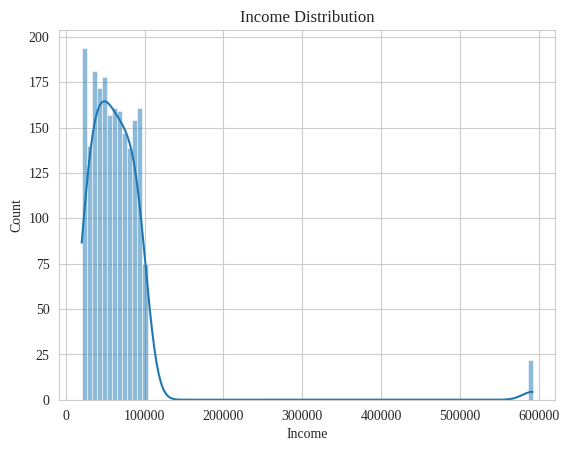

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(dataset['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

Handline outliers

1. Normalized data

In [ ]:
#Calculating the mean
mean_value = dataset['Income'].mean()
#Calculating the upper limit using standard deviation
upperLimit = dataset['Income'].mean()+3*dataset['Income'].std()
#Calculating the lower limit using standard deviation
lowerLimit = dataset['Income'].mean()-3*dataset['Income'].std()
print('Mean value:',mean_value)
print('Upper Limit:',upperLimit)
print('Lower Limit:',lowerLimit)
#--------------------------------
# Records without outliers
final_dataset_without_outlier = dataset[(dataset['Income'] < upperLimit) &
                      (dataset['Income'] > lowerLimit)]
print("Original dataset size:", dataset.shape[0])
print("After removing outliers:",final_dataset_without_outlier.shape[0])

Mean value: 64743.877368421054
Upper Limit: 244133.72468521274
Lower Limit: -114645.96994837062
Original dataset size: 2040
After removing outliers: 2018


2. Skewed data

In [ ]:
#Calculate the first quartile
Q1 = dataset['Income'].quantile(0.25)

#Calculate the 3rd quartile
Q3 = dataset['Income'].quantile(0.75)

#Calculate the interquartile range
IQR = Q3-Q1

#Calculate the upper limit
upperLimit = dataset['Income'].quantile(0.75)+1.5*IQR
#Calculate the lower limit
lowerLimit = dataset['Income'].quantile(0.75)-1.5*IQR
print('Upper Limit:',upperLimit)
print('Lower Limit:',lowerLimit)

# Remove outliers
final_dataset_without_outlier = dataset[(dataset['Income'] <= upperLimit)
                              & (dataset['Income'] >= lowerLimit)]

print("Original dataset size:", dataset.shape[0])
print("After removing outliers:", final_dataset_without_outlier.shape[0])

Upper Limit: 141980.75
Lower Limit: 18587.75
Original dataset size: 2040
After removing outliers: 2018


Handling duplicate records

In [ ]:
#Find the duplicate rows from the dataset
duplicate_rows = dataset[dataset.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0],
                        "out of",dataset.shape[0],"rows")

#Removing duplicates
dataset_with_no_duplicates = dataset.drop_duplicates()
print("Number of records after Removing Duplicates:"
                      ,dataset_with_no_duplicates.shape[0])

Number of duplicate rows: 40 out of 2040 rows
Number of records after Removing Duplicates: 2000


Handling disguised values

In [ ]:
#Check all the columns to find any unusual findings
for i in dataset.columns:
  print('----***Describing',i,'***----','\n')
  print(dataset[i].describe())
  print('--------------------')

----***Describing ID ***---- 

count     2040.000000
mean     11001.975490
std        577.527323
min      10001.000000
25%      10503.750000
50%      11001.500000
75%      11501.250000
max      12000.000000
Name: ID, dtype: float64
--------------------
----***Describing Birth Year ***---- 

count    1940.000000
mean     1974.978351
std        14.288725
min      1950.000000
25%      1963.000000
50%      1975.000000
75%      1987.000000
max      1999.000000
Name: Birth Year, dtype: float64
--------------------
----***Describing Education ***---- 

count         1940
unique           4
top       2n Cycle
freq           508
Name: Education, dtype: object
--------------------
----***Describing Marital Status ***---- 

count       2040
unique         4
top       Single
freq         554
Name: Marital Status, dtype: object
--------------------
----***Describing Income ***---- 

count      2040.000000
mean      64743.877368
std       59796.615772
min       20060.000000
25%       39153.250000
50

Correlation matrix

In [ ]:
# Correlation matrix
corr_matrix = dataset[['Income', 'Amount']].corr()
print(corr_matrix)

          Income    Amount
Income  1.000000  0.007595
Amount  0.007595  1.000000


Check if there is any high correlated columns

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("dataset.csv")

# Compute correlation only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Find all correlations
corr_unstacked = corr_matrix.unstack().sort_values(ascending=False)

# Remove self correlations (1.0 values)
corr_unstacked = corr_unstacked[corr_unstacked < 0.9999]

# Keep only pairs with correlation > 0.8
high_corr = corr_unstacked[corr_unstacked > 0.8].dropna()

if not high_corr.empty:
    print("Highly correlated column pairs (correlation > 80%):")
    print(high_corr)
else:
    print("No correlation found above 80%.")


No correlation found above 80%.


Draw the correlated heatmap

Top correlated column pairs:
Income                      Num Social Media Purchases    0.038111
Num Social Media Purchases  Income                        0.038111
Kids Home                   ID                            0.037711
ID                          Kids Home                     0.037711
Birth Year                  Income                        0.035621
dtype: float64


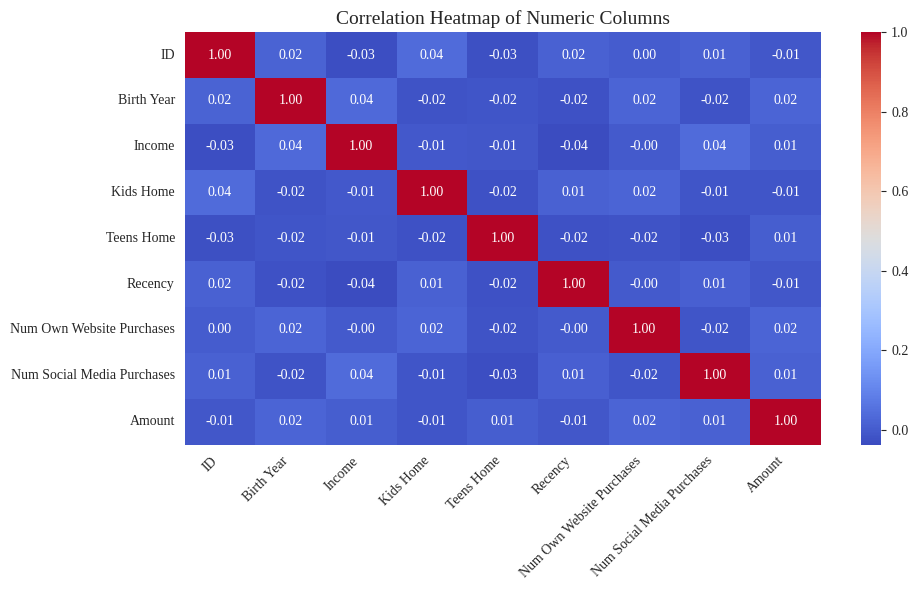

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dataset.csv")

# Compute correlation only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# ----- Print Top Correlations -----
corr_unstacked = corr_matrix.unstack().sort_values(ascending=False)
corr_unstacked = corr_unstacked[corr_unstacked < 0.9999]   # remove self-correlation
top_corr = corr_unstacked.dropna().head(5)

print("Top correlated column pairs:")
print(top_corr)

# ----- Plot Heatmap -----
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Numeric Columns", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Box plot - example

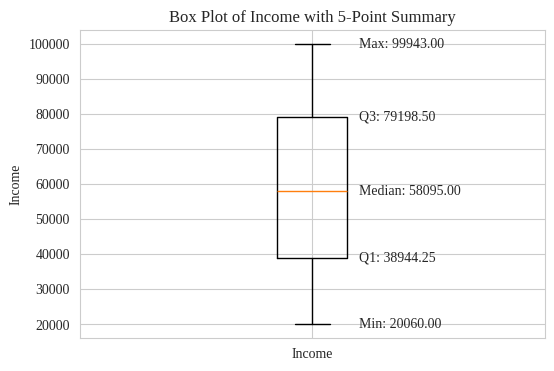

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the Income column
income = final_dataset_without_outlier['Income'].dropna()

# Calculate 5-point summary
minimum = np.min(income)
q1 = np.percentile(income, 25)
median = np.median(income)
q3 = np.percentile(income, 75)
maximum = np.max(income)

# Create box plot
plt.figure(figsize=(6,4))
plt.boxplot(income, vert=True)

# Set x-axis tick label
plt.xticks([1], ["Income"], fontfamily="Liberation Serif")

# Set y-axis tick labels font
plt.yticks(fontfamily="Liberation Serif")

# Add labels for 5-point summary with Palatino-like font
plt.text(1.1, minimum, f"Min: {minimum:.2f}", va='center', fontfamily='Liberation Serif')
plt.text(1.1, q1, f"Q1: {q1:.2f}", va='center', fontfamily='Liberation Serif')
plt.text(1.1, median, f"Median: {median:.2f}", va='center', fontfamily='Liberation Serif')
plt.text(1.1, q3, f"Q3: {q3:.2f}", va='center', fontfamily='Liberation Serif')
plt.text(1.1, maximum, f"Max: {maximum:.2f}", va='center', fontfamily='Liberation Serif')

# Titles with Palatino font
plt.title("Box Plot of Income with 5-Point Summary", fontfamily='Liberation Serif')
plt.ylabel("Income", fontfamily='Liberation Serif')

plt.show()


Scatter plot - example

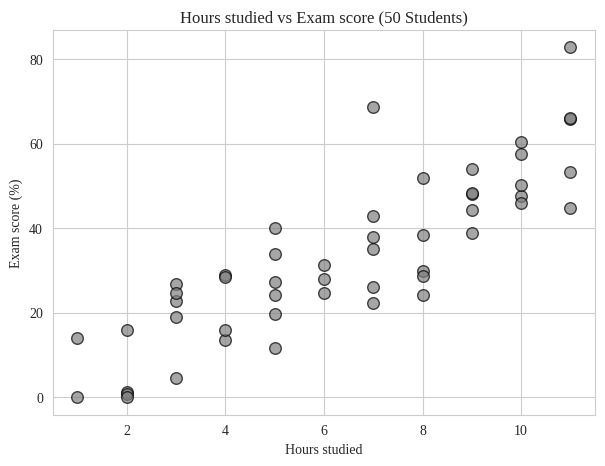

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Random seed for reproducibility
np.random.seed(42)

# Generate dataset
hours = np.random.randint(1, 12, 50)  # Hours studied between 1–11
scores = 5 * hours + np.random.normal(0, 10, 50)  # Exam score with noise

# Ensure scores are within 0–100
scores = np.clip(scores, 0, 100)

# Scatter plot in grey
plt.figure(figsize=(7,5))
plt.scatter(hours, scores, color="grey", s=70, edgecolors="black", alpha=0.7)

# Labels & Title
plt.title("Hours studied vs Exam score (50 Students)", fontfamily="Liberation Serif")
plt.xlabel("Hours studied", fontfamily="Liberation Serif")
plt.ylabel("Exam score (%)", fontfamily="Liberation Serif")
# Set x-axis tick label
plt.xticks(fontfamily="Liberation Serif")
plt.yticks(fontfamily="Liberation Serif")

plt.show()


Frequecy polygon - example

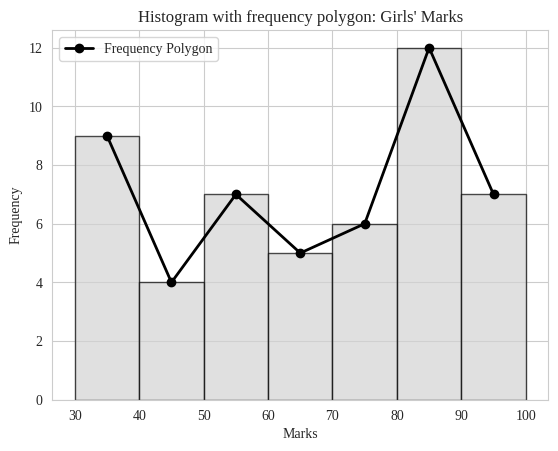

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 50 random marks for girls between 30 and 100
np.random.seed(42)  # for reproducibility
girls_marks = np.random.randint(30, 101, 50)

# Define bins
bins = range(30, 101, 10)  # from 30 to 100 with step of 10

# Plot Histogram
plt.hist(girls_marks, bins=bins, color="lightgrey", edgecolor="black", alpha=0.7)

# Plot Frequency Polygon on top of Histogram
counts, bin_edges = np.histogram(girls_marks, bins=bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, counts, marker="o", color="black", linewidth=2, label="Frequency Polygon")

# Labels & Title
plt.title("Histogram with frequency polygon: Girls' Marks", fontfamily="Liberation Serif")
plt.xlabel("Marks", fontfamily="Liberation Serif")
plt.ylabel("Frequency", fontfamily="Liberation Serif")
plt.xticks(fontfamily="Liberation Serif")
plt.yticks(fontfamily="Liberation Serif")
plt.legend()

plt.show()


Frequecy polygon - example, two data

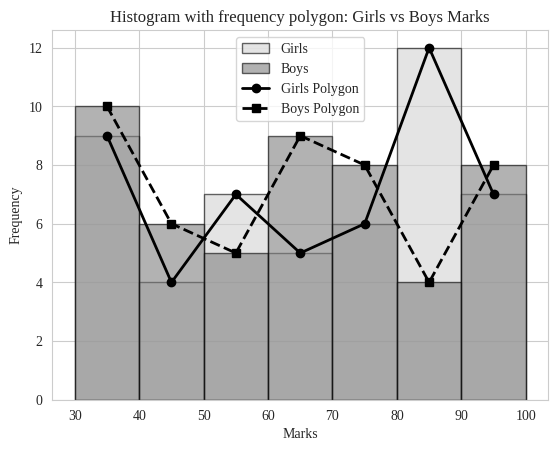

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 50 random marks for girls and boys between 30 and 100
np.random.seed(42)  # reproducibility
girls_marks = np.random.randint(30, 101, 50)
boys_marks = np.random.randint(30, 101, 50)

# Define bins
bins = range(30, 101, 10)

# Girls histogram (light grey)
plt.hist(girls_marks, bins=bins, color="lightgrey", edgecolor="black", alpha=0.6, label="Girls")

# Boys histogram (dark grey)
plt.hist(boys_marks, bins=bins, color="grey", edgecolor="black", alpha=0.6, label="Boys")

# Girls frequency polygon (black solid line)
counts_g, bin_edges = np.histogram(girls_marks, bins=bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, counts_g, marker="o", color="black", linestyle="-", linewidth=2, label="Girls Polygon")

# Boys frequency polygon (dashed black line)
counts_b, _ = np.histogram(boys_marks, bins=bins)
plt.plot(bin_centers, counts_b, marker="s", color="black", linestyle="--", linewidth=2, label="Boys Polygon")

# Labels & Title
plt.title("Histogram with frequency polygon: Girls vs Boys Marks", fontfamily="Liberation Serif")
plt.xlabel("Marks", fontfamily="Liberation Serif")
plt.ylabel("Frequency", fontfamily="Liberation Serif")
plt.xticks(fontfamily="Liberation Serif")
plt.yticks(fontfamily="Liberation Serif")
plt.legend()

plt.show()


Lag plot - example

/tmp/ipykernel_4899/3056825214.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2024-01-01", end="2024-08-01")
[*********************100%***********************]  1 of 1 completed


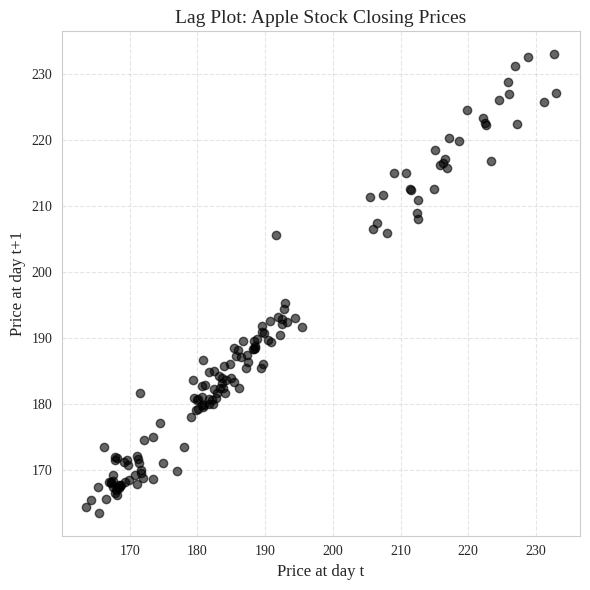

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Download historical stock data (Apple as example)
data = yf.download("AAPL", start="2024-01-01", end="2024-08-01")

# 2. Extract closing prices
close_prices = data['Close'].dropna()

# 3. Create lagged series
x_stock = close_prices[:-1]
y_stock = close_prices[1:]

# 4. Set Liberation Serif font
plt.rcParams["font.family"] = "Liberation Serif"

# 5. Plot lag plot
plt.figure(figsize=(6, 6))
plt.scatter(x_stock, y_stock, color="black", alpha=0.6)
plt.title("Lag Plot: Apple Stock Closing Prices", fontsize=14)
plt.xlabel("Price at day t", fontsize=12)
plt.ylabel("Price at day t+1", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Heat map - example

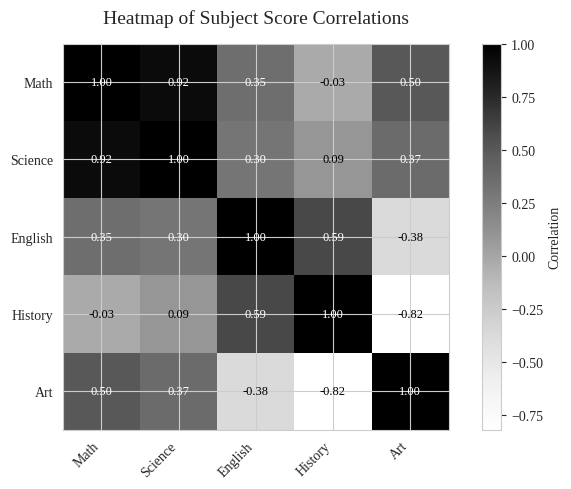

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create sample dataset (students' marks)
data = {
    "Math":    [88, 92, 80, 89, 100, 67, 78, 85],
    "Science": [90, 85, 79, 92, 95, 70, 80, 88],
    "English": [70, 78, 85, 72, 80, 65, 75, 90],
    "History": [60, 65, 70, 72, 75, 68, 80, 85],
    "Art":     [95, 90, 85, 88, 92, 80, 70, 65]
}

df = pd.DataFrame(data, index=[f"Student{i+1}" for i in range(8)])

# 2. Compute correlation matrix
corr_matrix = df.corr()

# 3. Set Liberation Serif font
plt.rcParams["font.family"] = "Liberation Serif"

# 4. Plot heatmap (Greyscale)
plt.figure(figsize=(7, 5))
im = plt.imshow(corr_matrix, cmap="Greys", interpolation="nearest")
plt.colorbar(label="Correlation")

# Add ticks & labels
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

# Add title
plt.title("Heatmap of Subject Score Correlations", fontsize=14, pad=15)

# 5. Annotate cells with correlation values
#    Pick white text if cell is dark, black if cell is light
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        value = corr_matrix.iloc[i, j]
        color = "white" if im.cmap(im.norm(value))[:3] < (0.5, 0.5, 0.5) else "black"
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=9)

plt.tight_layout()
plt.show()


Pair plot - example

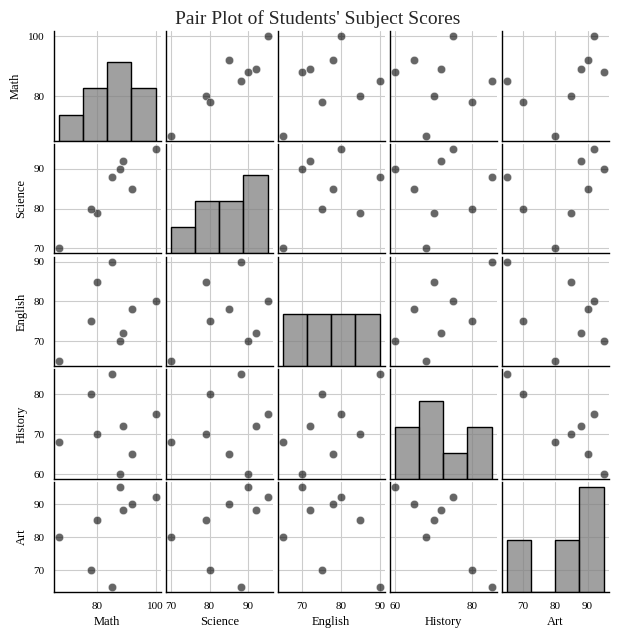

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample dataset
data = {
    "Math":    [88, 92, 80, 89, 100, 67, 78, 85],
    "Science": [90, 85, 79, 92, 95, 70, 80, 88],
    "English": [70, 78, 85, 72, 80, 65, 75, 90],
    "History": [60, 65, 70, 72, 75, 68, 80, 85],
    "Art":     [95, 90, 85, 88, 92, 80, 70, 65]
}
df = pd.DataFrame(data)

# 2. Set font globally
plt.rcParams["font.family"] = "Liberation Serif"

# 3. Pair plot in grey/black tones
sns.set_style("whitegrid")
pair_plot = sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={"color": "black", "alpha": 0.6},
    diag_kws={"color": "grey", "edgecolor": "black"}
)

# 4. Resize the figure (smaller for screenshots)
pair_plot.fig.set_size_inches(6, 6)

# 5. Title with font
pair_plot.fig.suptitle(
    "Pair Plot of Students' Subject Scores",
    fontsize=14,
    fontfamily="Liberation Serif",
    y=1.02
)

# 6. Apply font + dark axes
for ax in pair_plot.axes.flatten():
    if ax is not None:
        # Axis labels
        ax.set_xlabel(ax.get_xlabel(), fontsize=9, fontfamily="Liberation Serif", color="black")
        ax.set_ylabel(ax.get_ylabel(), fontsize=9, fontfamily="Liberation Serif", color="black")
        ax.set_title(ax.get_title(), fontsize=10, fontfamily="Liberation Serif", color="black")

        # Tick labels
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontfamily("Liberation Serif")
            label.set_fontsize(8)
            label.set_color("black")

        # Darker spines (axis lines)
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(1)

plt.show()


Bivariate analysis - heat map example

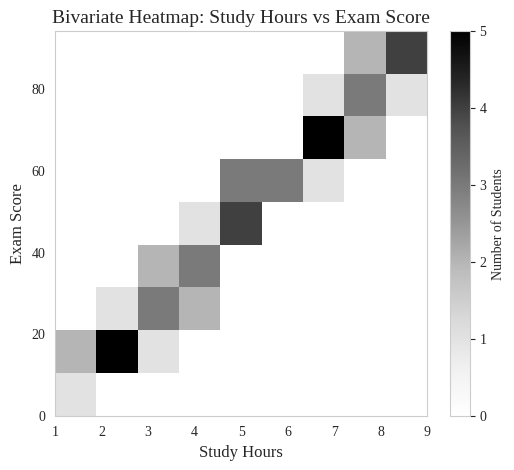

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sample dataset
np.random.seed(42)
study_hours = np.random.randint(1, 10, 50)   # Hours studied per day
exam_scores = study_hours * 10 + np.random.randint(-10, 10, 50)  # Exam scores with some randomness

df = pd.DataFrame({"Study Hours": study_hours, "Exam Score": exam_scores})

# 2. Set font globally
plt.rcParams["font.family"] = "Liberation Serif"

# 3. Create 2D bivariate heatmap (frequency count)
plt.figure(figsize=(6, 5))
heatmap, xedges, yedges, img = plt.hist2d(
    df["Study Hours"],
    df["Exam Score"],
    bins=(9, 9),
    cmap="Greys"
)

# 4. Add color bar
plt.colorbar(label="Number of Students")

# 5. Labels
plt.title("Bivariate Heatmap: Study Hours vs Exam Score", fontsize=14)
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)

plt.show()


Contour plot - example

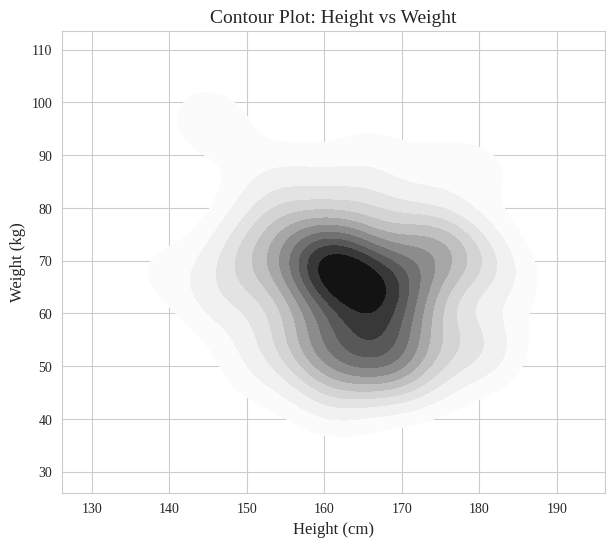

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate sample dataset (Height vs Weight)
np.random.seed(42)
heights = np.random.normal(165, 10, 100)   # mean=165cm, std=10
weights = np.random.normal(65, 12, 100)    # mean=65kg, std=12

df = pd.DataFrame({"Height (cm)": heights, "Weight (kg)": weights})

# 2. Set font
plt.rcParams["font.family"] = "Liberation Serif"

# 3. Contour plot
plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=df,
    x="Height (cm)",
    y="Weight (kg)",
    fill=True,       # Filled contour
    cmap="Greys",    # Shades of grey
    levels=12,       # Number of contour levels
    thresh=0.05      # Show only significant density
)

# 4. Labels
plt.title("Contour Plot: Height vs Weight", fontsize=14)
plt.xlabel("Height (cm)", fontsize=12)
plt.ylabel("Weight (kg)", fontsize=12)

plt.show()


Density plot - example

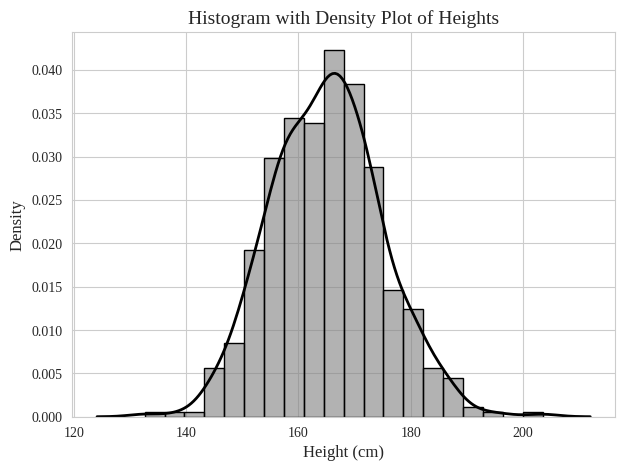

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate sample data
np.random.seed(42)
height = np.random.normal(165, 10, 500)   # cm

# 2. Set font
plt.rcParams["font.family"] = "Liberation Serif"

# 3. Plot histogram with density=True
plt.figure(figsize=(7, 5))
sns.histplot(height, bins=20, color="grey", stat="density", edgecolor="black", alpha=0.6)

# 4. Overlay smooth KDE
sns.kdeplot(height, color="black", linewidth=2)

# 5. Labels
plt.title("Histogram with Density Plot of Heights",
          fontsize=14, fontfamily="Liberation Serif")
plt.xlabel("Height (cm)", fontsize=12, fontfamily="Liberation Serif")
plt.ylabel("Density", fontsize=12, fontfamily="Liberation Serif")

plt.show()


Radar chart- example

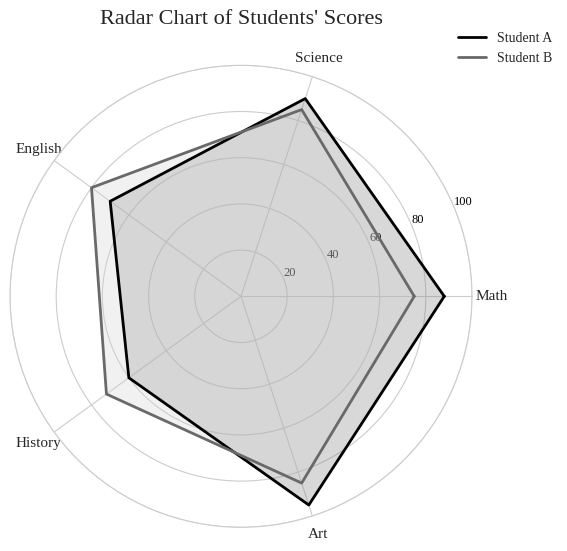

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data
categories = ["Math", "Science", "English", "History", "Art"]
student_A = [88, 90, 70, 60, 95]
student_B = [75, 85, 80, 72, 85]

# 2. Number of variables
N = len(categories)

# 3. Angles for each axis
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# 4. Data values (repeat first point to close shape)
values_A = student_A + student_A[:1]
values_B = student_B + student_B[:1]

# 5. Plot
plt.rcParams["font.family"] = "Liberation Serif"
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# Draw one student
ax.plot(angles, values_A, color="black", linewidth=2, label="Student A")
ax.fill(angles, values_A, color="grey", alpha=0.3)

# Draw another student
ax.plot(angles, values_B, color="dimgray", linewidth=2, label="Student B")
ax.fill(angles, values_B, color="lightgrey", alpha=0.3)

# Add category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontfamily="Liberation Serif")

# Add y-labels (score ticks)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], fontfamily="Liberation Serif", fontsize=9, color="black")

# Title
plt.title("Radar Chart of Students' Scores", fontsize=16, fontfamily="Liberation Serif",pad =30)

# Legend
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), frameon=False)

plt.show()


**Data Engineering steps**

1. Standardization (Schema + Format Enforcement)

In [ ]:
# Standardize column names (lowercase + underscore)
dataset.columns = [col.strip().lower().replace(" ", "_") for col in dataset.columns]

# Standardize data types
dataset["birth_year"] = dataset["birth_year"].astype("Int64")
dataset["income"] = dataset["income"].astype(float)
dataset["dt_customer"] = pd.to_datetime(dataset["dt_customer"])

# Standardize categorical values
dataset["education"] = dataset["education"].str.lower().str.strip()
dataset["marital_status"] = dataset["marital_status"].str.lower().str.strip()

print("Schema after standardization:\n", dataset.dtypes)

Schema after standardization:
 id                                     int64
birth_year                             Int64
education                             object
marital_status                        object
income                               float64
kids_home                            float64
teens_home                             int64
dt_customer                   datetime64[ns]
recency                                int64
num_own_website_purchases              int64
num_social_media_purchases             int64
amount                               float64
dtype: object


2. Conforming (Cross-source Alignment Simulation)

In [ ]:
# Example: Map inconsistent categories to standard values
education_mapping = {
    "phd": "postgraduate",
    "master": "postgraduate",
    "graduation": "graduate",
    "2n cycle": "undergraduate"
}

dataset["education"] = dataset["education"].map(education_mapping)

# Example: Create surrogate key
dataset["customer_key"] = range(1, len(dataset) + 1)

3. Applying business rules

In [ ]:
# Derive Age
current_year = 2024
dataset["age"] = current_year - dataset["birth_year"]

# Total dependents
dataset["total_dependents"] = dataset["kids_home"] + dataset["teens_home"]

# Business rule: Customer segmentation
def segment_customer(income):
    if income < 30000:
        return "low"
    elif income < 70000:
        return "medium"
    else:
        return "high"

dataset["income_segment"] = dataset["income"].apply(segment_customer)

4. Validation check (Data Quality)

In [ ]:
# Null checks
null_check = dataset.isnull().sum()

# Range checks
invalid_age = dataset[(dataset["age"] < 0) | (dataset["age"] > 100)]

# Uniqueness check
duplicate_keys = dataset["customer_key"].duplicated().sum()

# Summary
print("Null Check:\n", null_check)
print("Invalid Age Records:", len(invalid_age))
print("Duplicate Keys:", duplicate_keys)

Null Check:
 id                              0
birth_year                    100
education                     100
marital_status                  0
income                          0
kids_home                     101
teens_home                      0
dt_customer                     0
recency                         0
num_own_website_purchases       0
num_social_media_purchases      0
amount                        103
customer_key                    0
age                           100
total_dependents              101
income_segment                  0
dtype: int64
Invalid Age Records: 0
Duplicate Keys: 0


5. Publishing curated layer

In [ ]:
# Select only clean, business-ready columns
curated_dataset = dataset[
    [
        "customer_key",
        "age",
        "education",
        "marital_status",
        "income",
        "income_segment",
        "total_dependents",
        "amount"
    ]
]

# Save curated layer (Gold layer)
curated_dataset.to_csv("curated_dataset.csv", index=False)

print("Curated dataset published successfully")

Curated dataset published successfully


**Production ready checklist**

1. Schema checks

In [ ]:
expected_columns = {
    "customer_key": "int64",
    "age": "int64",
    "income": "float64"
}

for col, dtype in expected_columns.items():
    if col not in curated_dataset.columns:
        print(f"Missing column: {col}")

2. Incremental processing logic

In [ ]:
# Example: process only new data
last_processed_date = "2014-01-01"

incremental_data = dataset[dataset["dt_customer"] > last_processed_date]

print("Incremental rows:", incremental_data.shape[0])

Incremental rows: 678


3. Data quality test

In [ ]:
# % null threshold
null_percent = curated_dataset.isnull().mean() * 100

if (null_percent > 5).any():
    print("Warning: High null values detected")

# Distribution check
print(curated_dataset.describe())

       customer_key        age         income  total_dependents         amount
count   2040.000000     1940.0    2040.000000       1939.000000    1937.000000
mean    1020.500000  49.021649   64743.877368          1.961320   14299.005679
std      589.041594  14.288725   59796.615772          1.131247   39817.185109
min        1.000000       25.0   20060.000000          0.000000      68.000000
25%      510.750000       37.0   39153.250000          1.000000    5297.000000
50%     1020.500000       49.0   58427.000000          2.000000   10608.000000
75%     1530.250000       61.0   80284.250000          3.000000   15545.000000
max     2040.000000       74.0  592309.310526          4.000000  399940.000000


4. Reconcilliation

In [ ]:
# Row count reconciliation
source_count = len(dataset)
target_count = len(curated_dataset)

print("Source Count:", source_count)
print("Curated Count:", target_count)

# Basic sanity check
if target_count > source_count:
    print("Error: More records in target than source")

Source Count: 2040
Curated Count: 2040


5. Observability and monitoring

In [ ]:
import datetime

log = {
    "timestamp": datetime.datetime.now(),
    "rows_processed": len(dataset),
    "rows_published": len(curated_dataset),
    "null_issues": dataset.isnull().sum().sum()
}

print("Pipeline Log:", log)

Pipeline Log: {'timestamp': datetime.datetime(2026, 4, 28, 1, 25, 35, 774842), 'rows_processed': 2040, 'rows_published': 2040, 'null_issues': np.int64(605)}
